<a href="https://colab.research.google.com/github/prvallejoz/ejercicio3-mcib-b/blob/master/hotel_bookings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
data = pd.read_csv('hotel_bookings.csv')

# Display the first few rows of the dataset
print(data.head())  

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [3]:
data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [5]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [6]:
data.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [7]:
missing_values = data.isnull().sum()

In [8]:
missing_values

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [9]:
missing_values[missing_values > 0].sort_values(ascending=False)

company     112593
agent        16340
country        488
children         4
dtype: int64

In [10]:
#remove rows with missing values
data_cleaned = data.drop(columns=['agent', 'company'])

In [11]:
data_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [12]:
data.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [13]:
data_cleaned.isna().sum()

hotel                               0
is_canceled                         0
lead_time                           0
arrival_date_year                   0
arrival_date_month                  0
arrival_date_week_number            0
arrival_date_day_of_month           0
stays_in_weekend_nights             0
stays_in_week_nights                0
adults                              0
children                            4
babies                              0
meal                                0
country                           488
market_segment                      0
distribution_channel                0
is_repeated_guest                   0
previous_cancellations              0
previous_bookings_not_canceled      0
reserved_room_type                  0
assigned_room_type                  0
booking_changes                     0
deposit_type                        0
days_in_waiting_list                0
customer_type                       0
adr                                 0
required_car

In [14]:
data_cleaned['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

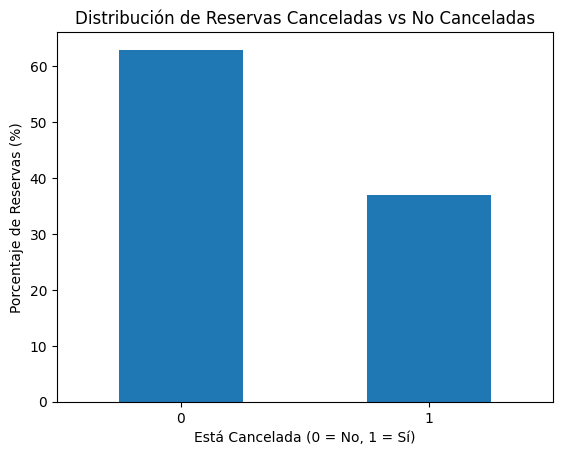

In [15]:

(data_cleaned['is_canceled'].value_counts(normalize=True) * 100).plot(kind='bar')

plt.title('Distribución de Reservas Canceladas vs No Canceladas')
plt.xlabel('Está Cancelada (0 = No, 1 = Sí)')
plt.ylabel('Porcentaje de Reservas (%)')
plt.xticks(rotation=0) 

plt.show()

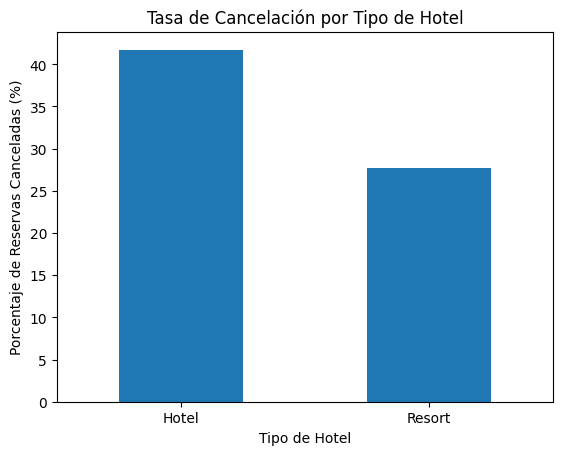

In [16]:
rate_by_type = data_cleaned.groupby('hotel')['is_canceled'].mean() * 100
rate_by_type.plot(kind='bar')
plt.xticks(ticks=[0, 1], labels=['Hotel', 'Resort'], rotation=0)
plt.title('Tasa de Cancelación por Tipo de Hotel')
plt.xlabel('Tipo de Hotel')
plt.ylabel('Porcentaje de Reservas Canceladas (%)')
plt.xticks(rotation=0)
plt.show()

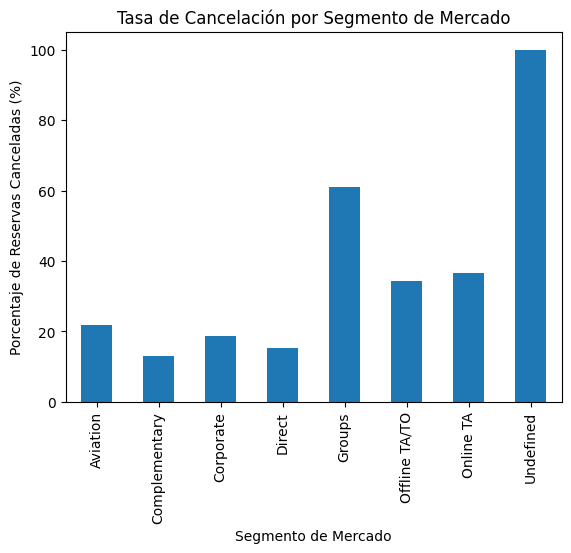

In [17]:
rate_by_market = data_cleaned.groupby('market_segment')['is_canceled'].mean() * 100
rate_by_market.plot(kind='bar')
plt.title('Tasa de Cancelación por Segmento de Mercado')
plt.xlabel('Segmento de Mercado') 
plt.ylabel('Porcentaje de Reservas Canceladas (%)')
plt.xticks(rotation=90)
plt.show()


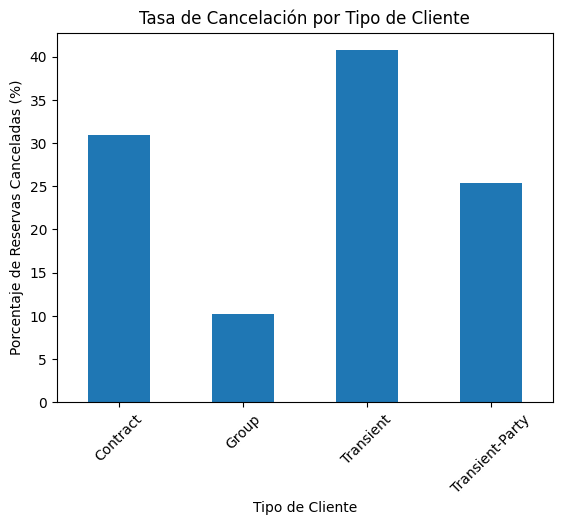

In [18]:
rate_by_customer_type = data_cleaned.groupby('customer_type')['is_canceled'].mean() * 100
rate_by_customer_type.plot(kind='bar') 
plt.title('Tasa de Cancelación por Tipo de Cliente')
plt.xlabel('Tipo de Cliente')
plt.ylabel('Porcentaje de Reservas Canceladas (%)')
plt.xticks(rotation=45)
plt.show()

In [20]:
matriz_corr = data_cleaned.select_dtypes(include=['float64', 'int64']).corr()

In [22]:
matriz_corr

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.000000,0.293123,0.016660,0.008148,-0.006130,-0.001791,0.024765,0.060017,0.005048,-0.032491,-0.084793,0.110133,-0.057358,-0.144381,0.054186,0.047557,-0.195498,-0.234658
lead_time,0.293123,1.000000,0.040142,0.126871,0.002268,0.085671,0.165799,0.119519,-0.037622,-0.020915,-0.124410,0.086042,-0.073548,0.000149,0.170084,-0.063077,-0.116451,-0.095712
arrival_date_year,0.016660,0.040142,1.000000,-0.540561,-0.000221,0.021497,0.030883,0.029635,0.054624,-0.013192,0.010341,-0.119822,0.029218,0.030872,-0.056497,0.197580,-0.013684,0.108531
arrival_date_week_number,0.008148,0.126871,-0.540561,1.000000,0.066809,0.018208,0.015558,0.025909,0.005518,0.010395,-0.030131,0.035501,-0.020904,0.005508,0.022933,0.075791,0.001920,0.026149
arrival_date_day_of_month,-0.006130,0.002268,-0.000221,0.066809,1.000000,-0.016354,-0.028174,-0.001566,0.014544,-0.000230,-0.006145,-0.027011,-0.000300,0.010613,0.022728,0.030245,0.008683,0.003062
stays_in_weekend_nights,-0.001791,0.085671,0.021497,0.018208,-0.016354,1.000000,0.498969,0.091871,0.045793,0.018483,-0.087239,-0.012775,-0.042715,0.063281,-0.054151,0.049342,-0.018554,0.072671
stays_in_week_nights,0.024765,0.165799,0.030883,0.015558,-0.028174,0.498969,1.000000,0.092976,0.044203,0.020191,-0.097245,-0.013992,-0.048743,0.096209,-0.002020,0.065237,-0.024859,0.068192
adults,0.060017,0.119519,0.029635,0.025909,-0.001566,0.091871,0.092976,1.000000,0.030447,0.018146,-0.146426,-0.006738,-0.107983,-0.051673,-0.008283,0.230641,0.014785,0.122884
children,0.005048,-0.037622,0.054624,0.005518,0.014544,0.045793,0.044203,0.030447,1.000000,0.024030,-0.032859,-0.024730,-0.021072,0.048949,-0.033273,0.324854,0.056253,0.081745
babies,-0.032491,-0.020915,-0.013192,0.010395,-0.000230,0.018483,0.020191,0.018146,0.024030,1.000000,-0.008943,-0.007501,-0.006550,0.083440,-0.010621,0.029186,0.037383,0.097889


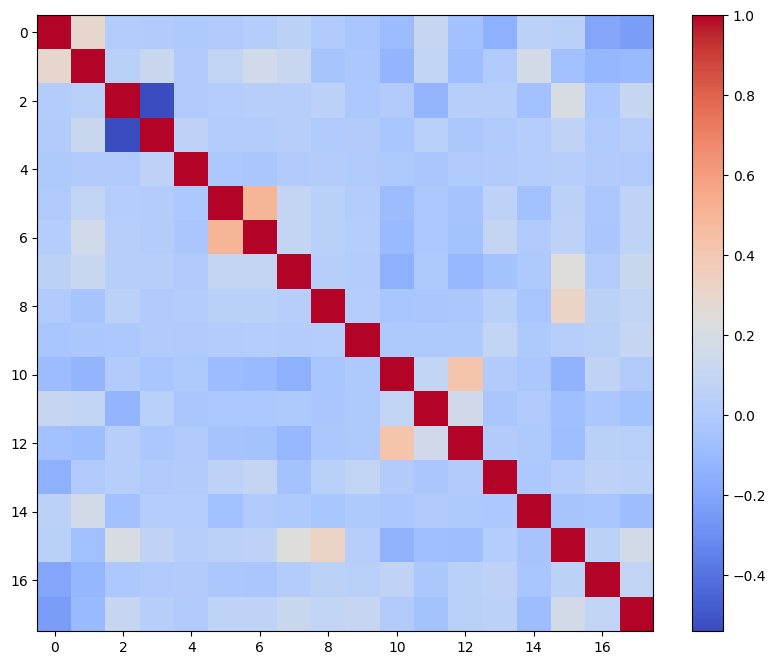

In [23]:
plt.figure(figsize=(10, 8))
plt.imshow(matriz_corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

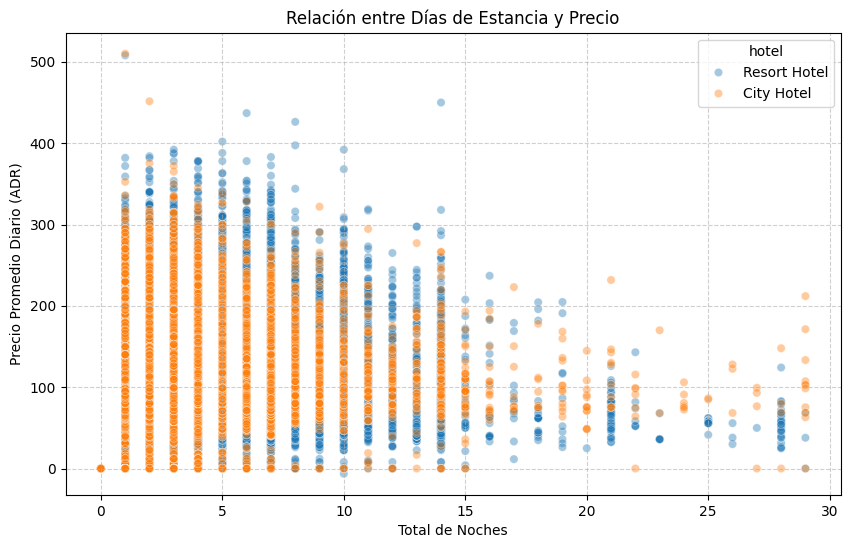

In [58]:


data_cleaned['total_nights'] = data_cleaned['stays_in_weekend_nights'] + data_cleaned['stays_in_week_nights']

df_plot = data_cleaned[(data_cleaned['adr'] < 1000) & (data_cleaned['total_nights'] < 30)]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='total_nights', y='adr', hue='hotel', alpha=0.4)
plt.title('Relación entre Días de Estancia y Precio')
plt.xlabel('Total de Noches')
plt.ylabel('Precio Promedio Diario (ADR)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

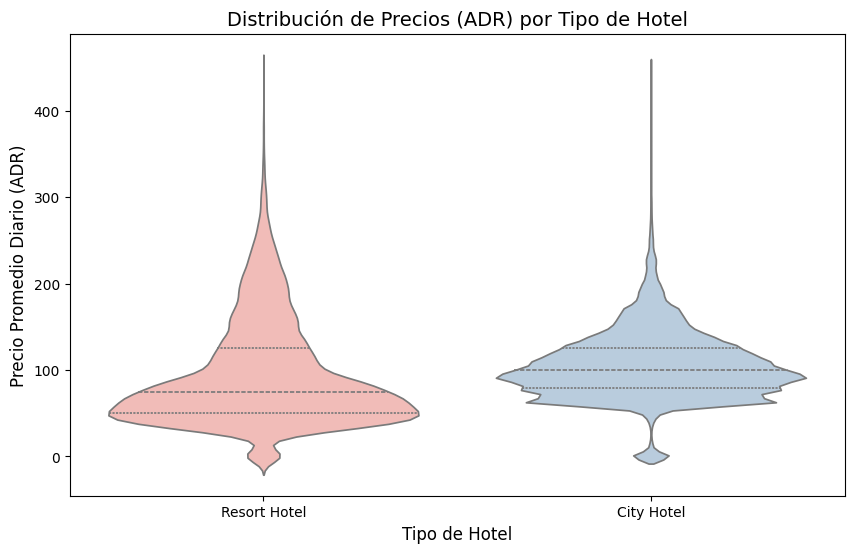

In [61]:
df_filtered = data_cleaned[data_cleaned['adr'] < 500]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_filtered, x='hotel', y='adr', palette='Pastel1', inner='quartile', hue='hotel')
plt.title('Distribución de Precios (ADR) por Tipo de Hotel', fontsize=14)
plt.xlabel('Tipo de Hotel', fontsize=12)
plt.ylabel('Precio Promedio Diario (ADR)', fontsize=12)

plt.show()

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

features = ['adr', 'lead_time', 'total_nights', 'previous_cancellations', 'required_car_parking_spaces']
X = data_cleaned[features]
y = data_cleaned['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(f"Precisión del modelo (Accuracy): {accuracy_score(y_test, y_pred):.2%}")
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

Precisión del modelo (Accuracy): 79.41%

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.82      0.86      0.84     22478
           1       0.75      0.67      0.71     13339

    accuracy                           0.79     35817
   macro avg       0.78      0.77      0.77     35817
weighted avg       0.79      0.79      0.79     35817



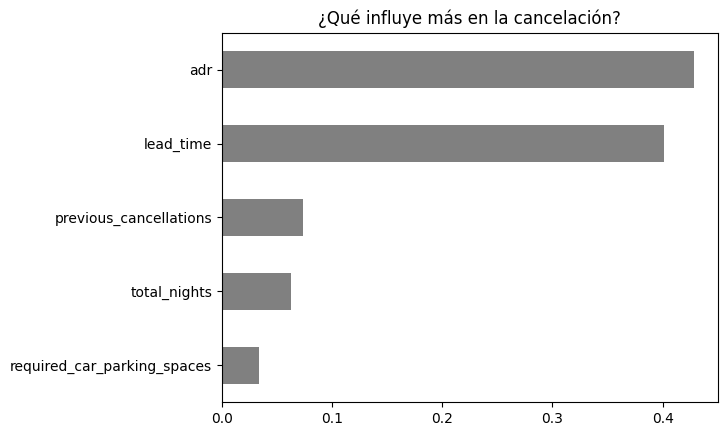

In [69]:

importances = pd.Series(rf_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='gray')
plt.title('¿Qué influye más en la cancelación?')
plt.show()

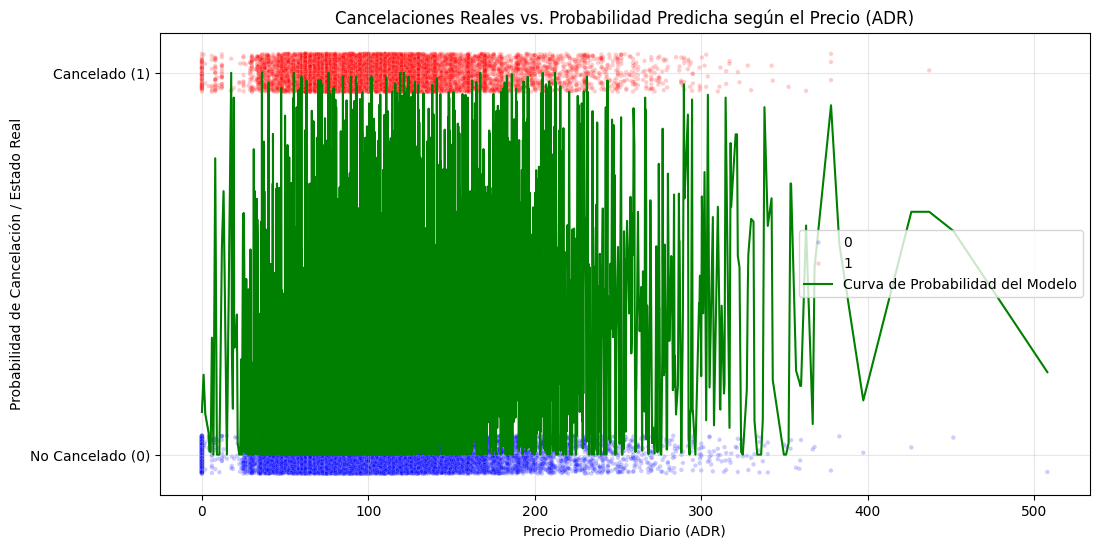

In [73]:

X = data_cleaned[['adr']]
y = data_cleaned['is_canceled']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)[:, 1] 

plot_df = X_test.copy()
plot_df['real'] = y_test
plot_df['predicho'] = y_pred
plot_df['probabilidad'] = y_probs


plt.figure(figsize=(12, 6))


sns.scatterplot(x=plot_df['adr'], 
                y=plot_df['real'] + np.random.uniform(-0.05, 0.05, size=len(plot_df)), 
                hue=plot_df['real'], palette={0: 'blue', 1: 'red'}, alpha=0.2, s=10,)


sns.lineplot(x=plot_df['adr'], y=plot_df['probabilidad'], color='green', label='Curva de Probabilidad del Modelo')

plt.title('Cancelaciones Reales vs. Probabilidad Predicha según el Precio (ADR)')
plt.xlabel('Precio Promedio Diario (ADR)')
plt.ylabel('Probabilidad de Cancelación / Estado Real')
plt.yticks([0, 1], ['No Cancelado (0)', 'Cancelado (1)'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

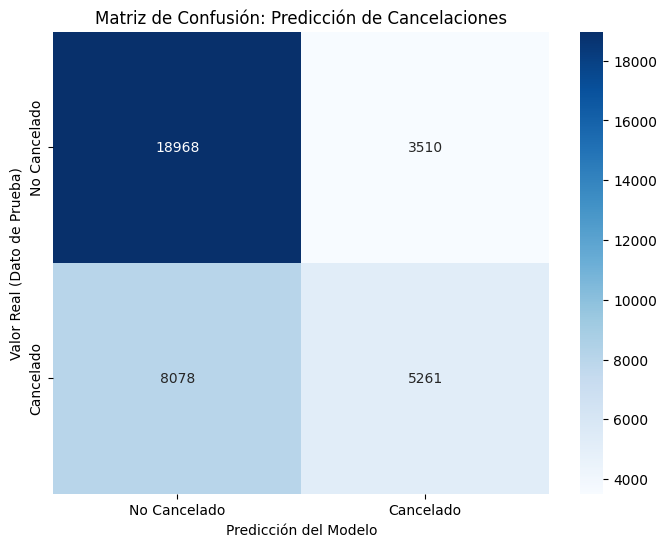

In [74]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Cancelado', 'Cancelado'], 
            yticklabels=['No Cancelado', 'Cancelado'])

plt.title('Matriz de Confusión: Predicción de Cancelaciones')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Dato de Prueba)')
plt.show()